<a href="https://colab.research.google.com/github/OlajideFemi/Carbon-Footprint/blob/main/ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

An ANOVA (Analysis of Variance) is a statistical formula used to compare the means of two or more groups to determine if at least one of them is significantly different from the others.

While a t-test is great for comparing two groups (like "Coffee Drinkers" vs. "Tea Drinkers"), ANOVA is your go-to when you have three or more groups (like "Coffee," "Tea," and "Energy Drinks") and you want to avoid the "family-wise error rate"—basically, the more t-tests you run, the higher the chance you'll find a "significant" result just by pure luck.

How It Works: The LogicInstead of looking at the means directly, ANOVA looks at variance. It breaks down the total variation in your data into two parts:Between-Group Variance: How much the means of the different groups differ from each other.Within-Group Variance: How much the individual scores inside each group differ from their own group mean (often called "noise" or "error").The F-statistic is then calculated:$$F = \frac{\text{Variance between groups}}{\text{Variance within groups}}$$High F-value: The groups are spread far apart compared to the noise within them, suggesting a significant difference.Low F-value: The differences between groups are small compared to the internal noise, suggesting any difference is likely due to chance.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)  # For reproducibility
data = {
    'Method_A': np.random.normal(loc=70, scale=10, size=30), # Mean=70
    'Method_B': np.random.normal(loc=72, scale=10, size=30), # Mean=72
    'Method_C': np.random.normal(loc=85, scale=10, size=30)  # Mean=85 (Clearly different)
}

# Convert to a DataFrame for easier handling
df = pd.DataFrame(data)

# 2. Perform One-Way ANOVA
# H0: All group means are equal
# H1: At least one group mean is different
f_stat, p_value = stats.f_oneway(df['Method_A'], df['Method_B'], df['Method_C'])

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically Significant (Reject H0)")
else:
    print("Result: Not Statistically Significant (Fail to reject H0)")

F-Statistic: 28.3049
P-Value: 0.0000
Result: Statistically Significant (Reject H0)


/tmp/ipykernel_17584/2785157634.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Score', data=df_melted, palette="Set2")


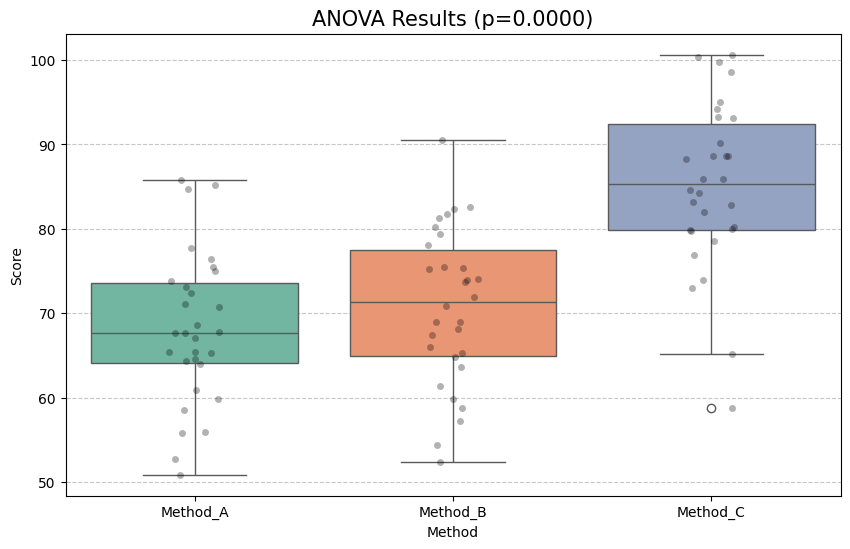

In [2]:
# Reshape data for plotting (Long-form)
df_melted = df.melt(var_name='Method', value_name='Score')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Method', y='Score', data=df_melted, palette="Set2")
sns.stripplot(x='Method', y='Score', data=df_melted, color="black", alpha=0.3) # Show raw data points

plt.title(f'ANOVA Results (p={p_value:.4f})', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()